In [1]:
import sys
sys.path.append('../')

In [6]:
from samrfi import RadioRFI

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

original_calib = '/home/gpuhost002/ddeal/RFI-AI/original_calib/calib_phase_tfcrop.ms'

datarfi_original = RadioRFI(vis=original_calib, dir_path=dir_path)
datarfi_original.load(mode='DATA', ant_i=1) # using first two antennas


Loading data...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:53<00:00, 53.71s/it]


(26, 4, 2048, 196)


In [8]:
import numpy as np

reflected_part = np.flip(datarfi_original.rfi_antenna_data, axis=-1)  # Alternatively, use arr[..., ::-1]
# Step 2: Concatenate along the last axis
new_arr = np.concatenate((datarfi_original.rfi_antenna_data, reflected_part), axis=-1)
datarfi_original.rfi_antenna_data = new_arr

In [9]:
datarfi_original.load(ant_i=1, mode='FLAG')


Loading data...


100%|██████████| 1/1 [00:21<00:00, 21.97s/it]


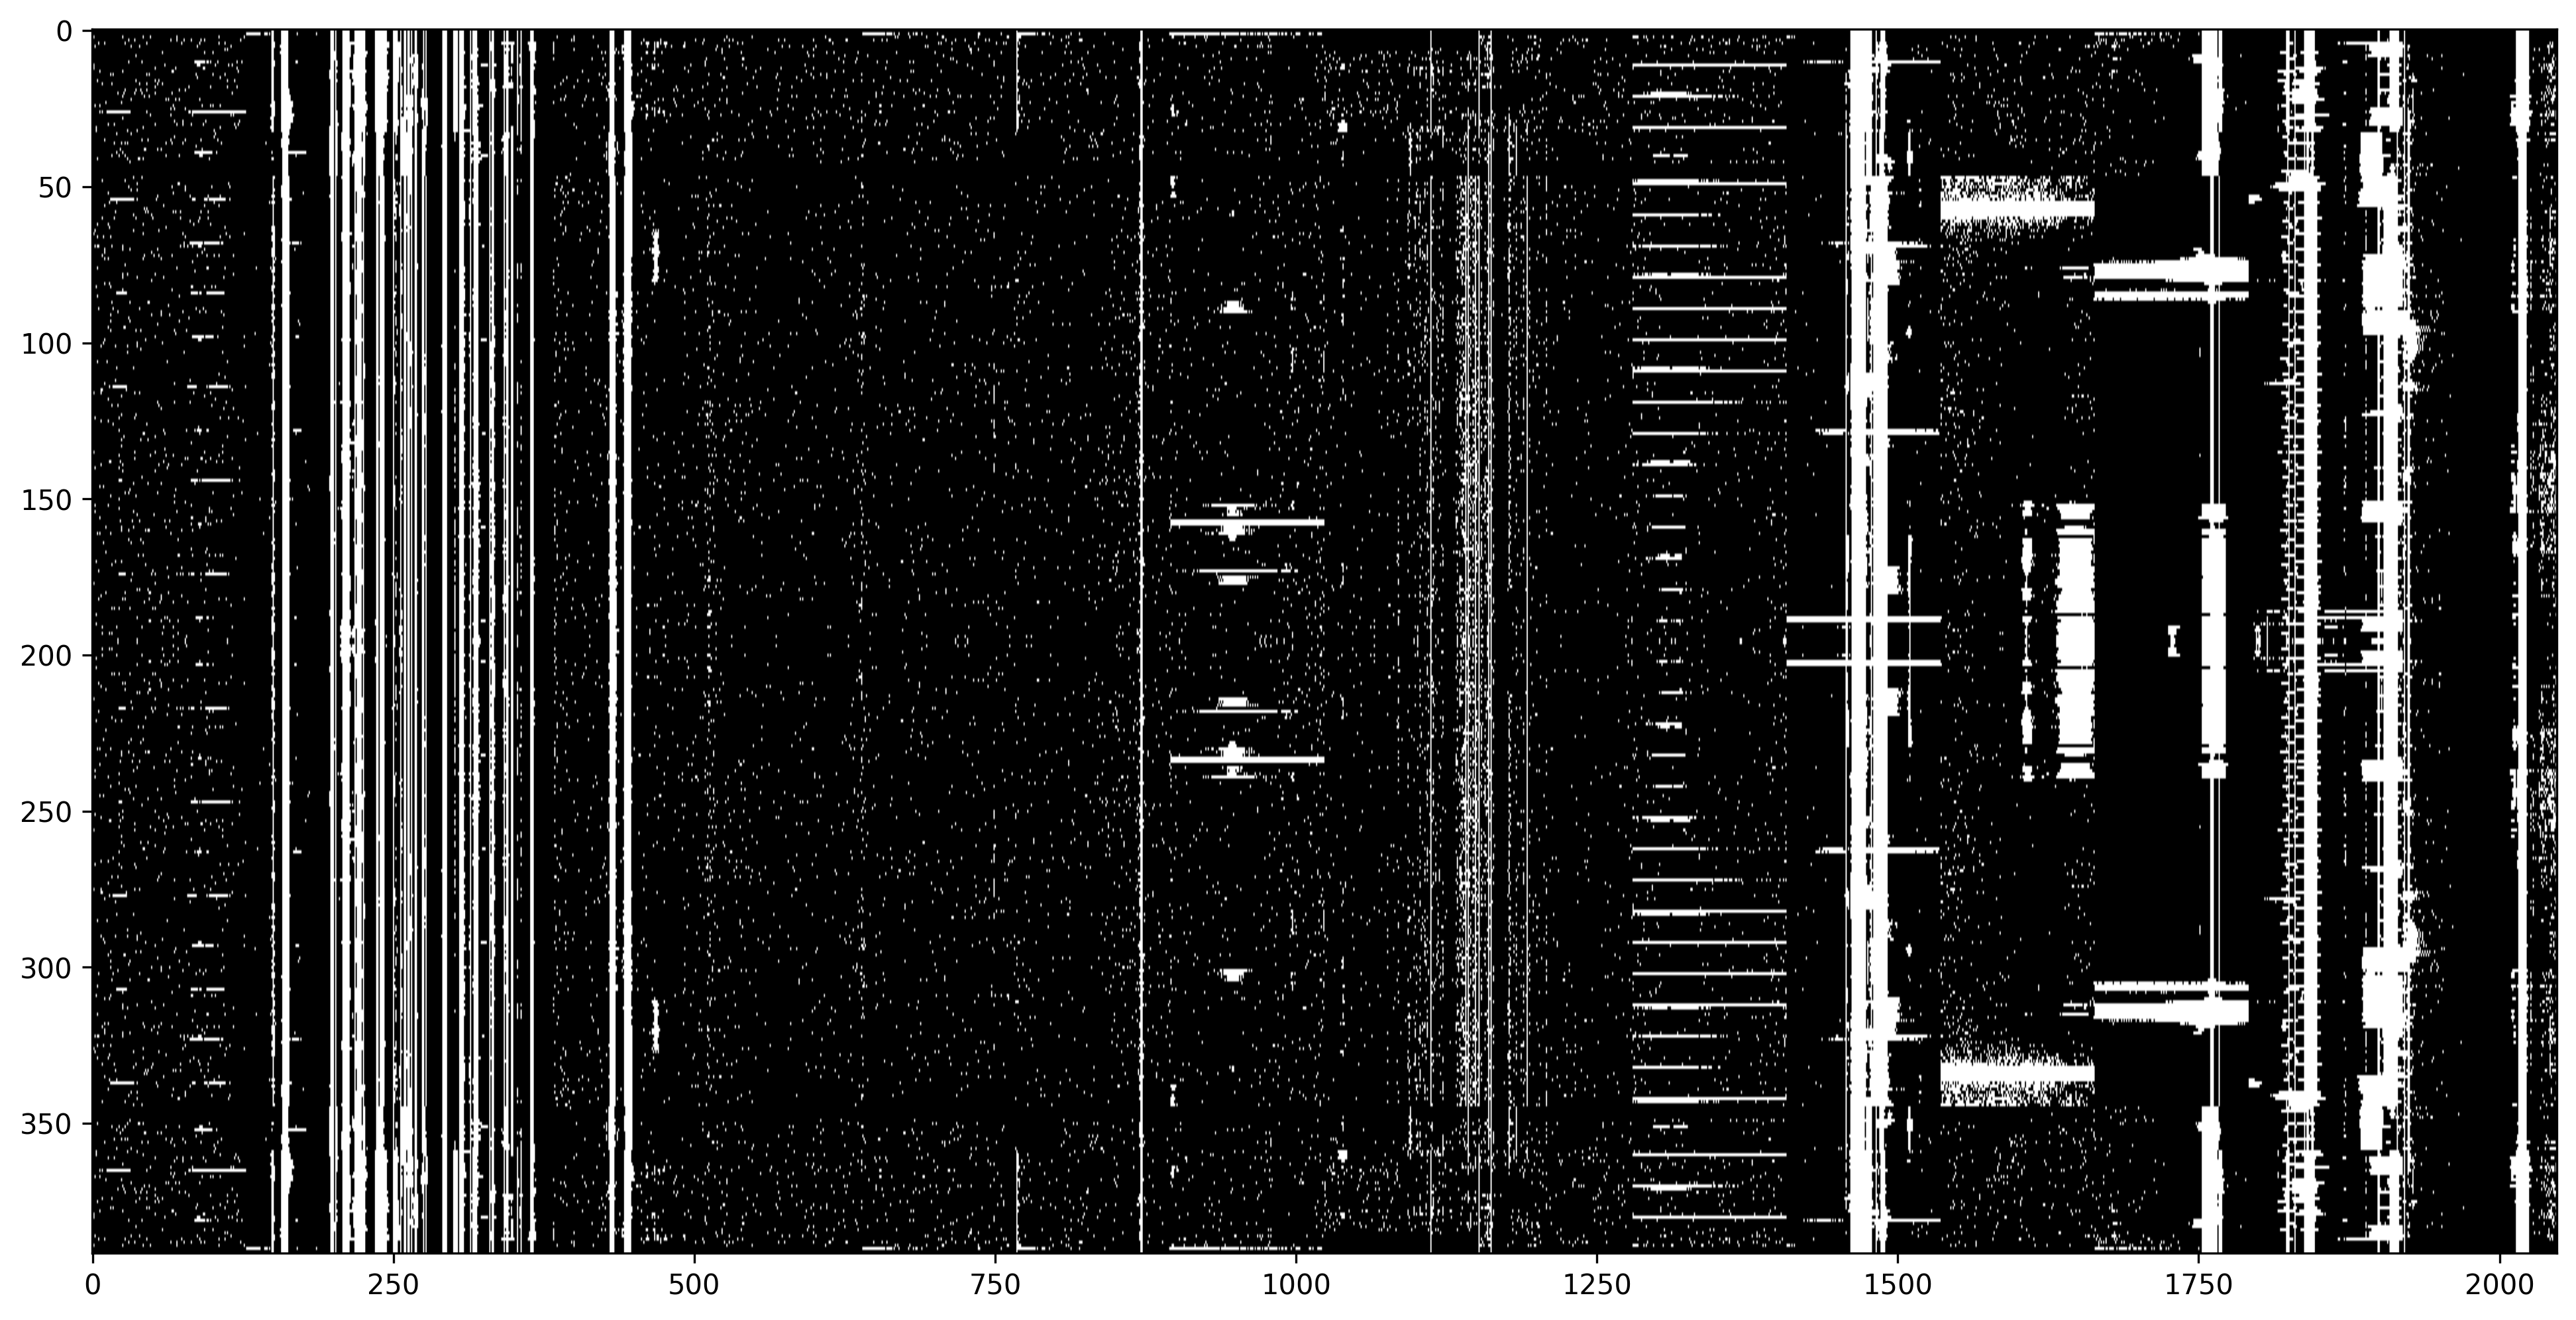

In [10]:
datarfi_original.flags = np.abs(datarfi_original.ms_flags)

reflected_part = np.flip(datarfi_original.flags, axis=-1)  # Alternatively, use arr[..., ::-1]
# Step 2: Concatenate along the last axis
new_arr = np.concatenate((datarfi_original.flags, reflected_part), axis=-1)
datarfi_original.flags = new_arr

datarfi_original.plotter.plot(mode='FLAG', baseline=15, polarization=0)

In [11]:
from samrfi import RFIDataset

rfi_dataset = RFIDataset(datarfi_original)
rfi_dataset.create_dataset(num_patches=600, patch_size=256, apply_stretching=False, custom_flag=True)


Applying median normalization only to 3328 patches...


100%|██████████| 3328/3328 [00:03<00:00, 880.68it/s]



Applying median normalization only to 3328 patches...


100%|██████████| 3328/3328 [00:03<00:00, 888.77it/s]


(3328, 256, 256) (3328, 256, 256)


In [5]:
from samrfi import RFIModels, RadioRFI

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

original_calib = '/home/gpuhost002/ddeal/RFI-AI/one_antenna_3C129.ms'

datarfi_3C129 = RadioRFI(vis=original_calib, dir_path=dir_path)
datarfi_3C129.load(mode='DATA', ant_i=1) # using first two antennas

# sam_checkpoint = "/home/gpuhost002/ddeal/RFI-AI/models/sam_vit_h_4b8939.pth"
# sam_type = "vit_h"

# model_path = "/home/gpuhost002/ddeal/RFI-AI/samrfi_data/models/model_stretch-3C147_tfcrop_patch-patchify_size-256_sam-huge_epochs60_20250103_175542.pth"
# model = RFIModels(sam_checkpoint, sam_type, radiorfi_instance=datarfi_3C129, device='cuda',)
# model.load_model(model_path)
# model.run_rfi_model(patch_run=True, sliding_patch=True, threshold=0.25)



Loading data...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:18<00:00, 18.75s/it]


(26, 4, 2048, 511)
